<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Classifying Document**

Estimated time needed: **60** minutes

Imagine working at a prestigious newspaper or magazine company that boasts an extensive archive of documents dating back through the annals of time. Amid this treasure trove of information, a monumental task lies ahead: organizing these historical documents into their relevant topic sections. This strategic curation not only promises to enhance the user experience by delivering more streamlined content but also presents an opportunity to breathe new life into invaluable insights from the past through a modern lens. However, the sheer volume and scope of this undertaking call for a sophisticated solution. 

![Documents Overload](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-GPXX0Y15EN/docs.png)

The implementation of an automated machine learning system makes it very efficient. Such a system, equipped with advanced natural language processing and machine learning capabilities, could sift through the vast archives, categorizing articles into their respective topics with remarkable precision. As a result, readers would seamlessly access a wealth of knowledge tailored to their interests, while the editorial team gains newfound agility in content management.

In this project, you will embark on the exciting task of classifying news articles for a content search engine. The goal is to build a model that can automatically categorize news articles into different topics or classes, enabling the search engine to deliver relevant content to users efficiently. To achieve this, you will leverage the powerful torchtext library, which simplifies the process of creating a dataset for text classification analysis.

With torchtext, you'll have the flexibility to access and preprocess raw news data effortlessly. The library enables you to convert text strings into torch.Tensors, which are essential for training machine learning models. By using torchtext's convenient functionalities, you can set up an efficient data processing pipeline that prepares your text data for classification.

Throughout this tutorial, you'll demonstrate how to effectively shuffle and iterate through the processed data using torch.utils.data.DataLoader. This DataLoader simplifies the data handling process, allowing you to focus on building and training your text classification model effectively.


---


# __Table of Contents__

<ol>
    <li><a href="#Objectives">Objectives</a></li>
    <li>
        <a href="#Setup">Setup</a>
        <ol>
            <li><a href="#Installing-required-libraries">Installing required libraries</a></li>
            <li><a href="#Importing-required-libraries">Importing required libraries</a></li>
            <li><a href="#Defining-helper-functions">Defining helper functions</a></li>
        </ol>
    </li>
    <li>
        <a href="#Text-classification">Text classification</a></li>
        <ol>
            <li><a href="#Import-bank-data-set">Import bank dataset</a></li>
            <li><a href="#Data-set">Dataset</a></li>
            <li><a href="#Data-loader">Data loader</a></li>
            <li><a href="#Neural-network">Neural network</a></li>
        </ol>
    <li><a href="#Train-the-model">Train The model</a></li>
    <li><a href="#Exercises">Exercises</a></li>
</ol>


# Objectives

After completing this lab, you will be able to:

- Work with datasets and understand tokenizer, embedding bag technique and vocabulary.
- Explore embeddings in PyTorch and understand token indices.
- Perform text classification using data loader and apply it on a neural network model.
- Train the text classification model on a news dataset.
- Engage in various exercises to solidify your understanding.


# Setup


## Install the Libraries

<h2 style="color:red;">After installing the libraries below please RESTART THE KERNEL and run all cells.</h2>



For this lab, you will use the following libraries:


The following required libraries are __not__ pre-installed in the Skills Network Labs environment. __You will need to run the following cell__ to install them:


### Importing required libraries


# NLP/DL Infrastructure Initialization

This cell initializes the complete infrastructure required for the NLP deep learning pipeline.

The imports collectively prepare the system for:

- Numerical computation using NumPy
- Deep learning operations using PyTorch
- Tokenization and vocabulary creation using TorchText
- Dataset loading and preprocessing
- Batch processing through DataLoader
- Neural network construction and training
- Embedding generation and representation learning
- Dataset splitting for training and validation
- Visualization of embeddings and training behavior
- Dimensionality reduction using t-SNE
- Interactive 3D embedding visualization using Plotly

Conceptually, this cell prepares the transition from:

Raw Human Language  
→ Token Processing  
→ Numerical Representation  
→ Tensor Pipeline  
→ Embedding Space  
→ Neural Network Training  
→ Semantic Classification

This is not the learning stage yet.

This cell only establishes the foundational NLP/DL engineering environment required for the complete text-classification pipeline.

In [1]:
from tqdm import tqdm
import numpy as np
import pandas as pd
from itertools import accumulate
import matplotlib.pyplot as plt
from torchtext.data.utils import get_tokenizer

import torch
import torch.nn as nn

from torch.utils.data import DataLoader
import numpy as np
from torchtext.datasets import AG_NEWS
from IPython.display import Markdown as md
from tqdm import tqdm

from torchtext.vocab import build_vocab_from_iterator
from torchtext.datasets import AG_NEWS
from torch.utils.data.dataset import random_split
from torchtext.data.functional import to_map_style_dataset
from sklearn.manifold import TSNE
import plotly.graph_objs as go
from sklearn.model_selection import train_test_split

from torchtext.data.utils import get_tokenizer

# You can also use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')


import torchtext
torchtext.disable_torchtext_deprecation_warning()

d:\My_Work\CourseRa\IBM_Generative_AI_Engineering\myenv\Lib\site-packages\torchtext\data\__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
d:\My_Work\CourseRa\IBM_Generative_AI_Engineering\myenv\Lib\site-packages\torchtext\datasets\__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
d:\My_Work\CourseRa\IBM_Generative_AI_Engineering\myenv\Lib\site-packages\torc

### Defining helper functions

_Use this section to define any helper functions to help the notebook's code readability:_

# Training Performance Visualization

This function visualizes the model's learning behavior during training.

It simultaneously plots:

- Loss reduction across epochs
- Accuracy improvement across epochs

Conceptually:

- Loss shows how wrong the model predictions are
- Accuracy shows how correct the model predictions are

The graph helps monitor:

Training Progress  
↓  
Optimization Quality  
↓  
Learning Stability  
↓  
Model Performance

Technical Details:

- Left Y-axis → Loss
- Right Y-axis → Accuracy
- X-axis → Epochs

This is a model evaluation and monitoring utility, not part of the neural learning pipeline itself.

In [2]:
def plot(COST,ACC):
    fig, ax1 = plt.subplots()
    color = 'tab:red'
    ax1.plot(COST, color=color)
    ax1.set_xlabel('epoch', color=color)
    ax1.set_ylabel('total loss', color=color)
    ax1.tick_params(axis='y', color=color)
    
    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('accuracy', color=color)  # you already handled the x-label with ax1
    ax2.plot(ACC, color=color)
    ax2.tick_params(axis='y', color=color)
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    
    plt.show()

---


The gif below gives you an overview.

![nlp](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-GPXX0Y15EN/NLP.gif)


---


## Text classification
Let's build a text classification model using PyTorch and torchtext to classify news articles into one of the four categories: World, Sports, Business, and Sci/Tech.


### Import bank dataset

Load the AG_NEWS dataset for the train split and split it into input text and corresponding labels:


In [3]:
train_iter= iter(AG_NEWS(split="train"))

The AG_NEWS dataset in torchtext does not support direct indexing like a list or tuple. It is not a random access dataset but rather an iterable dataset that needs to be used with an iterator. This approach is more effective for text data.


In [4]:
y,text= next((train_iter))
print(y,text)

3 Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


Find the label of the sample.


In [5]:
ag_news_label = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tec"}
ag_news_label[y]

'Business'

Also, use the dataset to find all the classes.


In [6]:
num_class = len(set([label for (label, text) in train_iter ]))
num_class 

4

#### Create the tokens as explained in previous lab and also build the vocabulary as before, just using the AG dataset to obtain token indices

# Vocabulary Construction and Tokenization Pipeline

This section builds the foundational NLP vocabulary system required for converting raw human language into numerical representations understandable by neural networks.

Pipeline Flow:

Raw News Articles  
↓  
Lowercase Normalization  
↓  
Tokenization  
↓  
Vocabulary Construction  
↓  
Token-to-Index Mapping  
↓  
Unknown Token Handling

Key Concepts:

- The tokenizer breaks sentences into smaller units called tokens.
- Lowercasing improves vocabulary consistency by avoiding duplicate tokens caused by capitalization differences.
- The vocabulary stores a mapping between words and unique numerical indices.
- `<unk>` represents unknown or unseen words during inference.
- `yield_tokens()` acts as a token generator that streams tokenized text into the vocabulary builder.

Example Transformation:

"AI Transforms Industries"  
↓  
["ai", "transforms", "industries"]  
↓  
[152, 847, 3921]

This stage represents the critical transition from:

Human Language  
→ Structured Numerical Representation

which becomes the foundation for embeddings, tensors, and neural network learning in NLP systems.

In [7]:
# Reinitialize train_iter
train_iter = AG_NEWS(split="train")

# Define tokenizer and yield_tokens
tokenizer = get_tokenizer("basic_english")

def yield_tokens(data_iter):
    for _, text in data_iter:
        yield tokenizer(text.lower())  # Lowercase conversion for consistency

# Build vocabulary
vocab = build_vocab_from_iterator(yield_tokens(train_iter), specials=["<unk>"])
vocab.set_default_index(vocab["<unk>"])

# Print the vocabulary size and sample tokens
print(f"Vocabulary size: {len(vocab)}")
print(f"Sample tokens: {list(vocab.get_stoi().keys())[:10]}")


Vocabulary size: 95811
Sample tokens: ['television', 'misnomer', 'television-watching', 'new', 'costs', '7-week', 'dutch', '35-10', 'tarceva', 'confidence']


Here are some token indices:


In [8]:
vocab(["age","hello", "zzz",'zzz', 'zygmunt', 'zwiki', 'zvidauri', 'zurine', 'zurab', 'zuo', 'zuloaga', 'zovko', 'zotinca'])

[2120,
 12544,
 95809,
 95809,
 95807,
 95806,
 95805,
 95803,
 95801,
 95800,
 95799,
 95792,
 95791]

### Dataset 


# Dataset Preparation and Data Splitting Pipeline

This section prepares the NLP dataset for neural network training, validation, and evaluation.

Pipeline Flow:

Raw Dataset  
↓  
Training/Test Separation  
↓  
Map-Style Dataset Conversion  
↓  
Train/Validation Split  
↓  
Model Training Pipeline

Key Concepts:

- `AG_NEWS()` loads the complete dataset and separates it into training and testing iterators.
- `to_map_style_dataset()` converts iterable datasets into indexable datasets compatible with DataLoader operations such as batching and shuffling.
- The dataset is divided into:
  - Training Set → used for learning model parameters
  - Validation Set → used for monitoring generalization and overfitting
  - Test Set → used for final unbiased evaluation

Dataset Distribution:

- 95% → Training Dataset
- 5% → Validation Dataset

Purpose of Validation Set:

- Monitor training quality
- Detect overfitting
- Tune hyperparameters
- Evaluate model generalization during training

This stage represents the transition from:

Raw NLP Dataset  
→ Structured Deep Learning Training Pipeline

The dataset is now fully prepared for batching, tensor conversion, embedding generation, and neural network training.

In [9]:
# Split the dataset into training and testing iterators.
train_iter, test_iter = AG_NEWS()

# Convert the training and testing iterators to map-style datasets.
train_dataset = to_map_style_dataset(train_iter)
test_dataset = to_map_style_dataset(test_iter)

# Determine the number of samples to be used for training and validation (5% for validation).
num_train = int(len(train_dataset) * 0.95)

# Randomly split the training dataset into training and validation datasets using `random_split`.
# The training dataset will contain 95% of the samples, and the validation dataset will contain the remaining 5%.
split_train_, split_valid_ = random_split(train_dataset, [num_train, len(train_dataset) - num_train])

The code checks if a CUDA-compatible GPU is available in the system using PyTorch, a popular deep learning framework. If a GPU is available, it assigns the device variable to "cuda" (which stands for CUDA, the parallel computing platform and application programming interface model developed by NVIDIA). If a GPU is not available, it assigns the device variable to "cpu" (which means the code will run on the CPU instead).


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Data loader


Prepare the text processing pipeline with the tokenizer and vocabulary. The text and label pipelines will be used to process the raw data strings from the dataset iterators. 

The function **```text_pipeline```** will tokenize the input text, and **```vocab```** will then be applied to get the token indices. 
The **```label_pipeline```** will ensure that the labels start at zero.

# Text and Label Processing Pipelines

Purpose:

This section converts:

- Raw text → Numerical token IDs
- Dataset labels → Zero-indexed class labels

Pipeline Flow:

Raw Sentence  
↓  
Tokenization  
↓  
Vocabulary Mapping  
↓  
Token IDs

Example:

"AI transforms industries"  
↓  
["ai", "transforms", "industries"]  
↓  
[52, 843, 1291]

Label Conversion:

1 → 0  
2 → 1  
3 → 2  
4 → 3

Reason:

PyTorch classification models require:
- numerical token inputs
- labels starting from index 0

This stage represents:

Human Language  
→ Neural-Network-Compatible Numerical Data

In [11]:
def text_pipeline(x):
  return vocab(tokenizer(x))

def label_pipeline(x):
   return int(x) - 1

In PyTorch, the **`collate_fn`** function is used in conjunction with data loaders to customize the way batches are created from individual samples. The provided code defines a `collate_batch` function in PyTorch, which is used with data loaders to customize batch creation from individual samples. It processes a batch of data, including labels and text sequences. It applies the `label_pipeline` and `text_pipeline` functions to preprocess the labels and texts, respectively. The processed data is then converted into PyTorch tensors and returned as a tuple containing the label tensor, text tensor, and offsets tensor representing the starting positions of each text sequence in the combined tensor. The function also ensures that the returned tensors are moved to the specified device (e.g., GPU) for efficient computation.


# Custom NLP Batch Processing Function

Purpose:

This function prepares variable-length text samples into neural-network-ready mini-batches for efficient deep learning training.

Core Responsibilities:

- Process raw text into token tensors
- Process labels into numerical targets
- Combine multiple sentences into a single batch tensor
- Track sentence boundaries using offsets
- Move tensors to CPU/GPU device

Pipeline Flow:

Raw Batch Samples  
↓  
Text Numericalization  
↓  
Tensor Conversion  
↓  
Sentence Flattening  
↓  
Offset Calculation  
↓  
Mini-Batch Construction

Key Concepts:

- `processed_text`
  - Converts token IDs into PyTorch tensors.

- `text_list`
  - Stores processed sentence tensors.

- `torch.cat(text_list)`
  - Merges all sentence tensors into one large flattened tensor for efficient computation.

- `offsets`
  - Tracks where each sentence begins inside the flattened tensor.
  - Required by `EmbeddingBag` to separate sentences correctly.

Example:

Sentence Lengths:

[3, 5, 2]

Offsets:

[0, 3, 8]

Meaning:

- Sentence 1 starts at index 0
- Sentence 2 starts at index 3
- Sentence 3 starts at index 8

Why This Function Is Important:

Traditional tabular datasets have fixed-size rows.

NLP sentences have variable lengths.

This custom batching logic enables neural networks to efficiently process language data despite varying sentence sizes.

Final Output:

- Label Tensor
- Flattened Text Tensor
- Offset Tensor

These outputs become direct inputs to the embedding and neural network layers.

In [ ]:
def collate_batch(batch):
    label_list, text_list, offsets = [], [], [0]
    
    for _label, _text in batch:
        label_list.append(label_pipeline(_label))
        processed_text = torch.tensor(text_pipeline(_text), dtype=torch.int64)
        
        text_list.append(processed_text)
        offsets.append(processed_text.size(0))
        
    label_list = torch.tensor(label_list, dtype=torch.int64)
    
    offsets = torch.tensor(offsets[:-1]).cumsum(dim=0)
    
    text_list = torch.cat(text_list)
    
    return label_list.to(device), text_list.to(device), offsets.to(device)

Convert the dataset objects to a data loader by applying the collate function.


# DataLoader and Mini-Batch Training Pipeline

Purpose:

This section creates automated mini-batch generators for training, validation, and testing of the NLP neural network model.

Core Responsibilities:

- Divide dataset into mini-batches
- Shuffle samples during training
- Apply custom NLP batching logic
- Feed batches efficiently into the neural network

Pipeline Flow:

Prepared Dataset  
↓  
Mini-Batch Creation  
↓  
Custom NLP Batch Processing  
↓  
Tensor Batch Generation  
↓  
Neural Network Training

Key Concepts:

- `BATCH_SIZE = 64`
  - The model processes 64 samples simultaneously in one training step.

- `shuffle=True`
  - Randomly shuffles data every epoch.
  - Prevents the model from memorizing data order patterns.
  - Improves optimization and generalization.

- `collate_fn=collate_batch`
  - Applies the custom NLP batching function.
  - Handles variable-length text sequences.
  - Creates:
    - label tensors
    - flattened text tensors
    - offset tensors

Three Separate DataLoaders:

- `train_dataloader`
  - Used for model learning and weight updates.

- `valid_dataloader`
  - Used for validation and performance monitoring during training.

- `test_dataloader`
  - Used for final unbiased evaluation after training completes.

Why DataLoader Is Important:

Deep learning models cannot process entire datasets at once.

DataLoader enables:

- efficient memory usage
- GPU-friendly processing
- automatic batching
- scalable training pipelines

This stage represents:

Prepared NLP Dataset  
→ Automated Deep Learning Training Pipeline

In [13]:
BATCH_SIZE = 64

train_dataloader = DataLoader(
    split_train_, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)
valid_dataloader = DataLoader(
    split_valid_, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)
test_dataloader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)

You can observe the output sequence when you have the label, text, and offsets for each batch.


# Inspecting a Processed NLP Mini-Batch

Purpose:

This section retrieves and inspects one fully processed mini-batch from the validation DataLoader.

Pipeline Flow:

Validation Dataset  
↓  
DataLoader  
↓  
Custom Batch Processing  
↓  
Mini-Batch Extraction

Key Components Returned:

- `label`
  - Tensor containing classification target labels for the batch samples.

- `text`
  - Flattened tensor containing tokenized and numericalized text data from all sentences in the batch.

- `offsets`
  - Tensor storing sentence starting positions inside the flattened text tensor.
  - Required by `EmbeddingBag` to correctly separate individual sentences.

What This Represents:

At this stage:

- Raw text has already been tokenized
- Tokens have already been converted to vocabulary indices
- Sentences have already been converted into tensors
- Variable-length sequences have already been merged into efficient mini-batches

This is the first point where the NLP data becomes fully:

Neural-Network-Ready Tensor Data

The output tensors generated here become direct inputs to the embedding layer and neural network training pipeline.

In [14]:
label, text, offsets=next(iter(valid_dataloader ))
label, text, offsets

(tensor([0, 2, 2, 2, 1, 0, 3, 1, 2, 0, 3, 3, 2, 3, 0, 2, 3, 1, 2, 2, 1, 0, 0, 3,
         3, 1, 0, 3, 1, 1, 2, 0, 2, 1, 1, 3, 2, 3, 1, 3, 1, 2, 3, 0, 1, 0, 3, 2,
         1, 3, 1, 1, 2, 0, 1, 1, 1, 2, 0, 0, 2, 2, 1, 3]),
 tensor([ 197,  346,    6,  ..., 8755,    3,   45]),
 tensor([   0,   42,   96,  128,  176,  215,  266,  309,  355,  404,  462,  506,
          524,  580,  627,  673,  718,  755,  793,  838,  875,  911,  949,  997,
         1031, 1067, 1103, 1133, 1179, 1220, 1258, 1285, 1331, 1380, 1412, 1461,
         1503, 1557, 1603, 1653, 1691, 1731, 1776, 1797, 1824, 1858, 1914, 1945,
         1978, 2010, 2040, 2082, 2115, 2152, 2201, 2239, 2284, 2326, 2376, 2418,
         2449, 2494, 2533, 2567]))

## THE BIGGEST THING TO UNDERSTAND

Till now:

NO actual learning has happened yet.

We only built:

the NLP preprocessing + batching + tensor pipeline.

Meaning:

# FINAL PIPELINE TILL HERE

Raw Sentence

↓

Tokenizer

↓

Vocabulary IDs

↓

Tensor Conversion

↓

Flattening

↓

Offset Tracking

↓

Mini-Batch Construction

↓

GPU-ready NLP Tensor Pipeline

# What We Actually Did Till Now

## We built:

## the ENTIRE language-to-neural-input pipeline.

# NLP Preprocessing and Neural Input Engineering — Progress Till This Stage

Till this point, no actual deep neural learning or semantic intelligence has started yet.

The neural network has not yet:
- learned patterns
- updated weights
- optimized parameters
- performed backpropagation
- generated semantic understanding

Instead, this entire stage focused on transforming raw human language into structured mathematical representations compatible with neural-network computation.

This is not simple data cleaning.

This is computational language structuring and neural input engineering.

Core Objective Achieved Till Here:

Human Language  
→ Neural-Network-Ready Tensor Infrastructure

Complete Pipeline Achieved:

Raw News Articles  
↓  
Tokenization  
↓  
Vocabulary Construction  
↓  
Word-to-Index Mapping  
↓  
Numerical Representation  
↓  
Tensor Conversion  
↓  
Mini-Batch Engineering  
↓  
Flattened Tensor Construction  
↓  
Offset Tracking  
↓  
GPU-Compatible Neural Input Pipeline

Key Achievements:

- Raw sentences were decomposed into tokens.
- Tokens were mapped into vocabulary indices.
- Human language was converted into numerical tensor structures.
- Variable-length text sequences were transformed into trainable mini-batches.
- Offsets were engineered to preserve sentence boundaries inside flattened tensors.
- DataLoaders automated the complete batch-generation pipeline.

Important Conceptual Understanding:

Traditional tabular machine learning often processes:
- fixed-size rows
- structured numerical columns

Modern NLP systems must process:
- variable-length language sequences
- semantic structures
- unstructured human text

Therefore, before neural learning can even begin, a sophisticated preprocessing and tensor-engineering pipeline must first be constructed.

At this stage, the system is now fully prepared for:

Embedding Generation  
↓  
Neural Forward Pass  
↓  
Loss Computation  
↓  
Backpropagation  
↓  
Weight Optimization  
↓  
Semantic Learning

This stage represents the transition from:

Human Language Processing  
→ Deep Learning Infrastructure Preparation

The actual neural intelligence and learning phase begins in the upcoming stages involving embeddings and neural network layers.

## Neural Network

#### What We Actually Did Till Now

We built:

the ENTIRE language-to-neural-input pipeline.

#### NOW About “Neurons”


Till now:

neurons have not meaningfully started learning patterns yet.

No real:

feature learning
weight updates
semantic learning
backpropagation

has happened yet.

WHY?

Because neural learning begins only AFTER:

input tensors enter neural layers

such as:

Embedding layer
Linear layer
RNN
Transformer
etc.

### CURRENT STATE OF THE PIPELINE

Right now you are standing EXACTLY here:


GPU-ready tensor batches
========================
NEURAL LEARNING HAS NOT REALLY STARTED YET
========================

# NLP Preprocessing and Neural Input Engineering — Progress Till This Stage

Till this point, no actual deep neural learning or semantic intelligence has started yet.

The neural network has not yet:
- learned patterns
- updated weights
- optimized parameters
- performed backpropagation
- generated semantic understanding

Instead, this entire stage focused on transforming raw human language into structured mathematical representations compatible with neural-network computation.

This is not simple data cleaning.

This is computational language structuring and neural input engineering.

Core Objective Achieved Till Here:

Human Language  
→ Neural-Network-Ready Tensor Infrastructure

Complete Pipeline Achieved:

Raw News Articles  
↓  
Tokenization  
↓  
Vocabulary Construction  
↓  
Word-to-Index Mapping  
↓  
Numerical Representation  
↓  
Tensor Conversion  
↓  
Mini-Batch Engineering  
↓  
Flattened Tensor Construction  
↓  
Offset Tracking  
↓  
GPU-Compatible Neural Input Pipeline

Key Achievements:

- Raw sentences were decomposed into tokens.
- Tokens were mapped into vocabulary indices.
- Human language was converted into numerical tensor structures.
- Variable-length text sequences were transformed into trainable mini-batches.
- Offsets were engineered to preserve sentence boundaries inside flattened tensors.
- DataLoaders automated the complete batch-generation pipeline.

Important Conceptual Understanding:

Traditional tabular machine learning often processes:
- fixed-size rows
- structured numerical columns

Modern NLP systems must process:
- variable-length language sequences
- semantic structures
- unstructured human text

Therefore, before neural learning can even begin, a sophisticated preprocessing and tensor-engineering pipeline must first be constructed.

At this stage, the system is now fully prepared for:

Embedding Generation  
↓  
Neural Forward Pass  
↓  
Loss Computation  
↓  
Backpropagation  
↓  
Weight Optimization  
↓  
Semantic Learning

This stage represents the transition from:

Human Language Processing  
→ Deep Learning Infrastructure Preparation

The actual neural intelligence and learning phase begins in the upcoming stages involving embeddings and neural network layers.

In [15]:
from torch import nn

class TextClassificationModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_class):
        super(TextClassificationModel, self).__init__()
        self.embedding = nn.EmbeddingBag(vocab_size, embed_dim, sparse=False)
        self.fc = nn.Linear(embed_dim, num_class)
        self.init_weights()

    def init_weights(self):
        initrange = 0.5
        self.embedding.weight.data.uniform_(-initrange, initrange)
        self.fc.weight.data.uniform_(-initrange, initrange)
        self.fc.bias.data.zero_()

    def forward(self, text, offsets):
        embedded = self.embedding(text, offsets)
        return self.fc(embedded)

### You have created a neural network for a text classification model using an `EmbeddingBag` layer, followed by a softmax output layer. Additionally, you have initialized the model using a specific method.

You have created the model, and the embedding dimension size is a free parameter.


#### Now the notebook has officially crossed from:

Data Engineering / NLP Preprocessing
→ into
Actual Deep Learning Architecture Construction

This is the first place where:

trainable parameters appear

neurons appear

learnable embeddings appear

forward propagation starts

logits get generated

predictions become possible

In [16]:
emsize=64

You need the vocabulary size to determine the number of embeddings.


In [17]:
vocab_size=len(vocab)
vocab_size

95811

You have also determined the number of classes for the output layer.


In [18]:
num_class 

4

Creating the model:


In [19]:
model = TextClassificationModel(vocab_size, emsize, num_class).to(device)
model

TextClassificationModel(
  (embedding): EmbeddingBag(95811, 64, mode='mean')
  (fc): Linear(in_features=64, out_features=4, bias=True)
)

The code line `predicted_label=model(text, offsets)` is used to obtain predicted labels from a machine learning model for a given input text and its corresponding offsets. The `model` is the machine learning model being used for text classification or similar tasks.


In [20]:
predicted_label=model(text, offsets)

Now, verify the output shape of your model. In this case, the model is trained with a mini-batch size of 64 samples. The output layer of the model produces four logits for each neuron, corresponding to the four classes in the classification task. You can also create a function to find the accuracy given a dataset.


In [21]:
predicted_label.shape

torch.Size([64, 4])

Function **`predict`** takes in a text and a text pipeline, which preprocesses the text for machine learning. It uses a pre-trained model to predict the label of the text for text classification on the AG_NEWS dataset. The function returns the predicted label as a result.


In [22]:
def predict(text, text_pipeline):
    with torch.no_grad():
        text = torch.tensor(text_pipeline(text))
        output = model(text, torch.tensor([0]))
        return ag_news_label[output.argmax(1).item() + 1]

In [23]:
predict("I like sports",text_pipeline )

'Sports'

In [24]:
predict("I like fashion",text_pipeline )

'Sports'

Create a function to evaluate the model's accuracy on a dataset.


In [25]:
def evaluate(dataloader):
    model.eval()
    total_acc, total_count= 0, 0

    with torch.no_grad():
        for idx, (label, text, offsets) in enumerate(dataloader):
            predicted_label = model(text, offsets)

            total_acc += (predicted_label.argmax(1) == label).sum().item()
            total_count += label.size(0)
    return total_acc / total_count

The model was evaluated, and it was found that its performance is no better than average. This outcome is expected, considering that the model has not undergone any training yet.


In [26]:
evaluate(test_dataloader)

0.2231578947368421

Your Current Position in the Pipeline

You are EXACTLY here:

Raw Text
↓

Tokenization
↓

Vocabulary
↓

Tensor Engineering
↓

DataLoader
↓

Neural Network Architecture Created

========================

TRAINING NOT STARTED YET

========================

# Neural Network Architecture Construction and NLP Inference Pipeline

This section represents the transition from:

NLP Preprocessing Infrastructure  
→ Actual Deep Learning Model Architecture

Till previous stages, the system only prepared language data for neural-network compatibility.

This section officially introduces:

- trainable neural parameters
- embeddings
- neural layers
- forward propagation
- logits
- inference
- evaluation pipeline

This is the point where actual neural intelligence infrastructure begins.

---

# 1. Creating the Neural Network Model Class

The custom class:

`TextClassificationModel(nn.Module)`

defines the architecture of the NLP classification system.

`nn.Module` is the foundational PyTorch class used to create all trainable neural networks.

This enables:

- trainable parameters
- GPU computation
- automatic gradient calculation
- optimizer compatibility
- forward propagation

At this stage, the AI model structure itself is officially created.

---

# 2. Model Configuration Parameters

The neural network receives:

- Vocabulary Size
- Embedding Dimension
- Number of Output Classes

These define:

- how many unique words exist
- how large each semantic word vector will be
- how many categories the classifier must predict

Example:

Vocabulary Size  
→ Total unique tokens learned from dataset

Embedding Dimension  
→ Size of learned semantic vector for each word

Number of Classes  
→ World, Sports, Business, Sci/Tech

---

# 3. EmbeddingBag Layer — Semantic Representation Learning

The `EmbeddingBag` layer is the first major neural NLP component.

Purpose:

Convert token IDs into trainable semantic vector representations.

Before embeddings:

"football" → 532

After embeddings:

"football" → [0.24, -0.91, 0.63, ...]

Now words gain:

- semantic meaning
- geometric relationships
- contextual similarity

Words with similar meanings gradually move closer together in vector space during training.

Example:

- football
- cricket
- basketball

eventually develop nearby vector representations.

This is one of the foundational ideas behind all modern NLP and LLM systems.

---

# 4. Why EmbeddingBag Is Used

Traditional embeddings return one vector per token.

EmbeddingBag efficiently combines all word vectors of a sentence into a single sentence-level representation.

Example:

"I love football"

↓

Single semantic sentence vector

instead of multiple independent word vectors.

This is computationally efficient for text classification tasks.

---

# 5. Fully Connected Linear Layer

The Linear layer acts as the classifier.

Input:

Sentence embedding vector

Output:

Class logits

Example:

[
World_score,
Sports_score,
Business_score,
SciTech_score
]

These are not probabilities yet.

They are raw neural confidence scores called logits.

---

# 6. Weight Initialization

Initially, the neural network knows absolutely nothing.

All embeddings and neural weights begin with random values.

Weight initialization prepares:

- embedding vectors
- classifier weights
- biases

for stable optimization during training.

At this stage:

the model contains only random intelligence structures.

No learning has occurred yet.

---

# 7. Forward Propagation Definition

The `forward()` function defines how information flows through the neural network.

Pipeline:

Token IDs  
↓  
Embedding Lookup  
↓  
Sentence Embedding Generation  
↓  
Linear Classification Layer  
↓  
Class Logits

This is the core computational path of the neural network.

Every future prediction and training step follows this exact flow.

---

# 8. Embedding Generation Stage

The embedding layer receives:

- flattened token tensor
- offsets tensor

Using these:

- token IDs become semantic vectors
- sentence boundaries are reconstructed
- sentence embeddings are generated

This is where raw numerical token IDs finally become semantic representations.

This stage is the beginning of actual representation learning.

---

# 9. Classification Layer Output

The sentence embeddings are passed into the linear classifier layer.

Output shape:

[Batch_Size, Number_of_Classes]

Example:

[64, 4]

Meaning:

- 64 samples in one batch
- 4 classification scores per sample

Each sample now contains neural confidence values for every category.

---

# 10. Embedding Dimension

Each token is represented using a high-dimensional semantic vector.

Example:

Embedding Dimension = 64

Meaning:

Every word becomes a 64-dimensional semantic representation.

This creates a learnable semantic space where neural relationships between words emerge during training.

---

# 11. Vocabulary and Embedding Matrix

The embedding layer internally creates a massive trainable matrix:

Vocabulary_Size × Embedding_Dimension

Example:

95811 × 64

Meaning:

Every unique word receives its own trainable semantic vector.

This embedding matrix becomes one of the most important learned components of the model.

---

# 12. Model Construction

The complete neural architecture is instantiated.

At this stage:

the AI model officially exists.

However:

the model is still untrained.

All weights remain random.

No semantic intelligence has emerged yet.

---

# 13. Forward Pass Execution

The statement:

`predicted_label = model(text, offsets)`

executes the complete neural forward propagation pipeline.

Internally:

Flattened Token Tensor  
↓  
Embedding Lookup  
↓  
Sentence Embedding Creation  
↓  
Linear Transformation  
↓  
Class Logits

This produces neural predictions for each sample.

---

# 14. Output Tensor Shape

Output shape:

[64, 4]

Meaning:

- 64 samples processed simultaneously
- 4 class scores generated per sample

Each row represents one article’s neural classification scores.

---

# 15. Prediction Function

The prediction pipeline performs:

Raw Text  
↓  
Tokenization  
↓  
Vocabulary Mapping  
↓  
Tensor Conversion  
↓  
Forward Pass  
↓  
Logit Generation  
↓  
Argmax Selection  
↓  
Final Category Prediction

This is the complete NLP inference pipeline.

---

# 16. Argmax Selection

The neural network outputs raw class scores.

Argmax selects the class with the highest confidence score.

Example:

[
0.2,
2.1,
-0.4,
0.7
]

↓

Highest Score = 2.1

↓

Predicted Class = Sports

This converts neural outputs into final human-readable predictions.

---

# 17. Evaluation Mode

The evaluation function switches the model into inference mode.

This disables training-specific behaviors and prepares the network for validation/testing.

Purpose:

- stable inference
- memory optimization
- deterministic evaluation

---

# 18. No Gradient Tracking

During evaluation:

gradients are disabled.

Reason:

- no learning occurs during evaluation
- reduces memory consumption
- speeds up inference

At this stage:

the model only predicts.

It does not update weights.

---

# 19. Accuracy Computation

The evaluation loop compares:

Predicted Labels  
vs  
True Labels

Correct predictions are counted to calculate overall model accuracy.

This becomes the primary performance metric for the classifier.

---

# 20. Most Important Conceptual Understanding

Till this stage:

the system has completed two gigantic engineering tasks:

---

## A. NLP Tensor Infrastructure Engineering

Raw Language  
↓  
Tokenization  
↓  
Vocabulary Construction  
↓  
Numericalization  
↓  
Tensor Conversion  
↓  
Batch Engineering  
↓  
Offset Tracking  
↓  
GPU-Compatible NLP Pipeline

---

## B. Neural Architecture Construction

Embedding Layer  
↓  
Sentence Representation System  
↓  
Classifier Layer  
↓  
Forward Propagation Pipeline  
↓  
Inference System  
↓  
Evaluation Pipeline

---

# CRITICAL FINAL REALIZATION

Even now:

actual neural learning has NOT truly started yet.

The system has only:

- prepared language data
- constructed neural architecture
- initialized random parameters
- defined forward computation logic

Training, optimization, backpropagation, and semantic learning begin in the upcoming stages.

This notebook therefore represents the complete transition from:

Human Language Processing  
→ Neural Semantic Learning Infrastructure

## Let's train the model.


---


## Train the model

Set the learning rate (LR) to 0.1, which determines the step size at which the optimizer updates the model's parameters during training. The CrossEntropyLoss criterion is used to calculate the loss between the model's predicted outputs and the ground truth labels. This loss function is commonly employed for multi-class classification tasks.

The chosen optimizer is Stochastic Gradient Descent (SGD), which optimizes the model's parameters based on the computed gradients with respect to the loss function. The SGD optimizer uses the specified learning rate to control the size of the weight updates.

Additionally, a learning rate scheduler is defined using StepLR. This scheduler adjusts the learning rate during training, reducing it by a factor (gamma) of 0.1 after every epoch (step) to improve convergence and fine-tune the model's performance. These components together form the essential setup for training a neural network using the specified learning rate, loss criterion, optimizer, and learning rate scheduler.


In [27]:
LR=0.1

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.1)

Training the model, which should take about 20 minutes.


In [28]:
EPOCHS = 10
cum_loss_list=[]
acc_epoch=[]
acc_old=0

for epoch in tqdm(range(1, EPOCHS + 1)):
    model.train()
    cum_loss=0
    for idx, (label, text, offsets) in enumerate(train_dataloader):
        optimizer.zero_grad()

        predicted_label = model(text, offsets)
        
        loss = criterion(predicted_label, label)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
        optimizer.step()
        cum_loss+=loss.item()

    cum_loss_list.append(cum_loss)
    accu_val = evaluate(valid_dataloader)
    acc_epoch.append(accu_val)

    if accu_val > acc_old:
      acc_old= accu_val
      torch.save(model.state_dict(), 'my_model.pth')

100%|██████████| 10/10 [05:19<00:00, 31.99s/it]


You can plot the cost and accuracy for each epoch. You'll see that with just ten epochs, you achieve an accuracy of over 80% on the validation data. You can increase the number of epochs to observe further results.


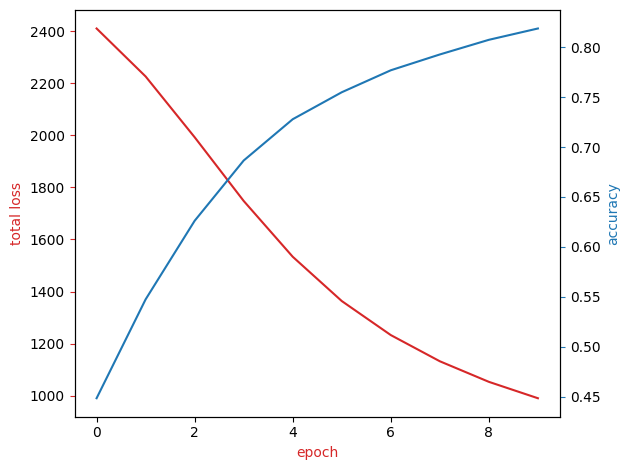

In [29]:
plot(cum_loss_list,acc_epoch)

You can evaluate the results on the test data and achieve over 80%.


In [30]:
evaluate(test_dataloader)

0.8163157894736842

# Deep Learning Training Pipeline — Neural Learning and Optimization

This section represents the actual beginning of neural intelligence learning.

Till previous stages:

- NLP preprocessing was completed
- tensors and batches were prepared
- neural architecture was constructed
- embeddings and classifier layers were initialized

However:

the model still contained only random weights.

No real learning had happened yet.

This section officially begins:

- optimization
- backpropagation
- semantic learning
- weight updates
- representation refinement

This is the core heart of Deep Learning.

---

# 1. Defining the Learning Rate

```python
LR = 0.1
```

The Learning Rate controls:

how aggressively the neural network updates its weights during learning.

High Learning Rate:
- faster updates
- potentially unstable learning

Low Learning Rate:
- slower learning
- more stable optimization

The learning rate is one of the most important hyperparameters in deep learning systems.

---

# 2. Defining the Loss Function

```python
criterion = torch.nn.CrossEntropyLoss()
```

The loss function measures:

how wrong the model predictions are.

The neural network outputs logits (raw class scores).

Example:

```text
[1.2, 4.5, -0.7, 0.3]
```

The loss function compares:

- predicted scores
- actual correct labels

and calculates a numerical prediction error.

Purpose:
- guide neural learning
- provide optimization direction
- quantify model mistakes

Lower loss means:
the model predictions are improving.

---

# 3. Defining the Optimizer

```python
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
```

The optimizer is responsible for:

updating neural weights to reduce prediction errors.

SGD = Stochastic Gradient Descent

Purpose:
- move weights in better directions
- minimize loss
- improve prediction quality

The optimizer is the engine that performs neural learning.

Without an optimizer:
the network cannot improve itself.

---

# 4. Learning Rate Scheduler

```python
scheduler = torch.optim.lr_scheduler.StepLR(...)
```

The scheduler gradually reduces the learning rate during training.

Purpose:
- large updates during early learning
- smaller fine-tuning adjustments later

This stabilizes optimization and improves convergence.

The learning process becomes more precise over time.

---

# 5. Defining Epochs

```python
EPOCHS = 10
```

An Epoch means:

one complete pass over the entire training dataset.

Example:

1 Epoch:
- model sees every training sample once

10 Epochs:
- model studies the dataset ten times

Multiple epochs allow the network to gradually refine its knowledge.

---

# 6. Tracking Training Metrics

```python
cum_loss_list = []
acc_epoch = []
acc_old = 0
```

These variables store:

- total loss per epoch
- validation accuracy per epoch
- best observed accuracy

Purpose:
- monitor learning progress
- visualize optimization behavior
- save the best model

---

# 7. Beginning the Training Loop

```python
for epoch in tqdm(range(1, EPOCHS + 1)):
```

This begins iterative neural learning.

The network repeatedly:
- predicts
- makes mistakes
- receives corrections
- improves itself

This loop is the foundation of deep learning optimization.

---

# 8. Switching the Model to Training Mode

```python
model.train()
```

This activates training behavior inside the neural network.

Certain neural components behave differently during:
- training
- evaluation

This prepares the model for gradient-based optimization.

---

# 9. Batch-Level Training

```python
for idx, (label, text, offsets) in enumerate(train_dataloader):
```

The dataset is processed batch-by-batch instead of sample-by-sample.

Advantages:
- efficient GPU computation
- stable gradient estimation
- faster optimization
- scalable training

Each batch contains:
- labels
- flattened token tensors
- offsets

---

# 10. Clearing Previous Gradients

```python
optimizer.zero_grad()
```

PyTorch accumulates gradients by default.

Without resetting:
gradients from previous batches would incorrectly stack together.

This line clears old gradients before computing new ones.

This is essential for stable learning.

---

# 11. Forward Propagation

```python
predicted_label = model(text, offsets)
```

This executes the complete neural forward pass.

Pipeline:

```text
Tokens
↓
Embeddings
↓
Sentence Representation
↓
Linear Layer
↓
Class Logits
```

The network generates predictions for the current batch.

At this stage:
the model attempts to classify each article.

---

# 12. Loss Computation

```python
loss = criterion(predicted_label, label)
```

The predicted outputs are compared against:
the true labels.

The loss function calculates:
how incorrect the predictions are.

Purpose:
- quantify prediction error
- generate optimization signal
- guide backpropagation

This becomes the mathematical learning signal for the network.

---

# 13. Backpropagation

```python
loss.backward()
```

This is one of the most important operations in deep learning.

Backpropagation computes:

- which parameters caused prediction errors
- how much each weight contributed
- how weights should change

Gradients are calculated for:
- embedding vectors
- classifier weights
- biases
- all trainable parameters

This is where neural learning mathematics happens.

---

# 14. Gradient Clipping

```python
torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
```

Purpose:
prevent exploding gradients.

Sometimes gradient values become extremely large and destabilize training.

Gradient clipping:
- stabilizes optimization
- prevents destructive updates
- improves NLP training reliability

This is especially important in sequence and NLP systems.

---

# 15. Updating Neural Weights

```python
optimizer.step()
```

This is the actual learning moment.

The optimizer uses computed gradients to:
- modify embeddings
- adjust classifier weights
- improve neural parameters

At this point:
the model becomes slightly smarter.

Neural intelligence gradually emerges through repeated updates.

---

# 16. Tracking Epoch Loss

```python
cum_loss += loss.item()
```

The total loss for the current epoch is accumulated.

Purpose:
- monitor optimization quality
- visualize learning behavior
- analyze convergence

Loss reduction over epochs indicates successful learning.

---

# 17. Validation Evaluation

```python
accu_val = evaluate(valid_dataloader)
```

After each epoch:
the model is evaluated on unseen validation data.

Purpose:
- measure generalization ability
- monitor learning quality
- detect overfitting

The validation dataset helps determine whether the model is learning meaningful patterns instead of memorizing training samples.

---

# 18. Saving the Best Model

```python
torch.save(model.state_dict(), 'my_model.pth')
```

If validation accuracy improves:
the model weights are saved.

This preserves:
- learned embeddings
- classifier weights
- neural knowledge

The saved model can later be:
- reloaded
- deployed
- reused for inference

---

# 19. Plotting Learning Curves

```python
plot(cum_loss_list, acc_epoch)
```

The graph visualizes:

- training loss
- validation accuracy

Expected healthy behavior:

```text
Loss ↓
Accuracy ↑
```

This indicates:
- successful optimization
- stable learning
- meaningful representation learning

The graph confirms whether the network is improving properly.

---

# 20. Final Test Evaluation

```python
evaluate(test_dataloader)
```

This evaluates the trained model on:
completely unseen test data.

Purpose:
measure real-world generalization performance.

Example Result:

```text
0.8163
```

Meaning:
approximately 81.6% classification accuracy.

This indicates:
the model has successfully learned meaningful semantic patterns from language data.

---

# FINAL CORE DEEP LEARNING PIPELINE

The complete training process can now be summarized as:

```text
Raw Language
↓
Tokenization
↓
Vocabulary Mapping
↓
Tensor Conversion
↓
Batch Engineering
↓
Embedding Generation
↓
Forward Propagation
↓
Prediction
↓
Loss Calculation
↓
Backpropagation
↓
Gradient Computation
↓
Weight Updates
↓
Learning
↓
Evaluation
↓
Final Classification
```

---

# MOST IMPORTANT FINAL UNDERSTANDING

This entire section represents:

neural self-improvement through mathematical optimization.

The model repeatedly performs:

```text
Predict
↓
Measure Error
↓
Compute Gradients
↓
Adjust Parameters
↓
Improve Predictions
```

This optimization cycle is the foundational mechanism behind:

- NLP systems
- transformers
- GPT models
- LLM fine-tuning
- recommendation systems
- computer vision
- generative AI

This is the exact point where:

mathematics transforms into learned intelligence.

This code snippet provides a summary for generating a 3D t-SNE visualization of embeddings using Plotly. It demonstrates how words that are similar to each other are positioned closer together.


In [31]:
# Get the first batch from the validation data
batch = next(iter(valid_dataloader))

# Extract the text and offsets from the batch
label, text, offsets = batch

# Send the data to the device (GPU if available)
text = text.to(device)
offsets = offsets.to(device)

# Get the embeddings bag output for the batch
embedded = model.embedding(text, offsets)

# Convert the embeddings tensor to a numpy array
embeddings_numpy = embedded.detach().cpu().numpy()

# Perform t-SNE on the embeddings to reduce their dimensionality to 3D.
X_embedded_3d = TSNE(n_components=3).fit_transform(embeddings_numpy)

# Create a 3D scatter plot using Plotly
trace = go.Scatter3d(
    x=X_embedded_3d[:, 0],
    y=X_embedded_3d[:, 1],
    z=X_embedded_3d[:, 2],
    mode='markers',
    marker=dict(
        size=5,
        color=label.numpy(),  # Use label information for color
        colorscale='Viridis',  # Choose a colorscale
        opacity=0.8
    )
)

layout = go.Layout(title="3D t-SNE Visualization of Embeddings",
                   scene=dict(xaxis_title='Dimension 1',
                              yaxis_title='Dimension 2',
                              zaxis_title='Dimension 3'))

fig = go.Figure(data=[trace], layout=layout)
fig.show()

  File "d:\My_Work\CourseRa\IBM_Generative_AI_Engineering\myenv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\My_Work\CourseRa\IBM_Generative_AI_Engineering\myenv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "d:\My_Work\CourseRa\IBM_Generative_AI_Engineering\myenv\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\My_Work\CourseRa\IBM_Generative_AI_Engineering\myenv\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\My_Work\CourseRa\IBM_Generative_AI_Engineering\myenv\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi

# Embedding Visualization and Semantic Space Analysis

This section performs:

# Neural Embedding Visualization

The purpose of this code is NOT training.

The model has already learned semantic representations during training.

This section helps us:

- inspect learned embeddings
- visualize semantic relationships
- understand how the neural network internally represents language

This is a very important NLP and Deep Learning analysis technique.

---

# 1. Getting One Batch from Validation Data

```python
batch = next(iter(valid_dataloader))
```

The validation dataloader contains:
- labels
- token tensors
- offsets

This line retrieves:
# one complete mini-batch

from the validation dataset.

Example:
- 64 news articles
- their labels
- their tokenized representations

This batch will later be passed through the embedding layer.

---

# 2. Extracting Labels, Text, and Offsets

```python
label, text, offsets = batch
```

The batch contains three major components:

---

## Labels

The actual target categories.

Example:

```text
World
Sports
Business
Sci/Tech
```

Internally stored as:
- 0
- 1
- 2
- 3

---

## Text Tensor

A flattened tensor containing:
all token IDs from all articles in the batch.

Example:

```text
[15, 82, 991, 7, 41, ...]
```

These numbers represent:
vocabulary indices.

---

## Offsets

Offsets define:
where each article starts inside the flattened tensor.

Purpose:
reconstruct sentence boundaries during embedding lookup.

This is especially important for `EmbeddingBag`.

---

# 3. Sending Data to Device

```python
text = text.to(device)
offsets = offsets.to(device)
```

The tensors are moved to:
- GPU (if available)
or
- CPU

Purpose:
ensure neural computations happen on the correct hardware accelerator.

Without this:
PyTorch device mismatch errors can occur.

---

# 4. Extracting Embeddings from the Model

```python
embedded = model.embedding(text, offsets)
```

This is one of the most important lines in the notebook.

The trained embedding layer converts:
token IDs
→ semantic vectors.

This produces:
# sentence embeddings

not raw token IDs anymore.

At this stage:

the neural network transforms language into mathematical semantic representations.

---

# Example Conceptually

Before Embedding:

```text
"football" → 532
```

After Embedding:

```text
"football" →
[0.18, -0.92, 0.44, ...]
```

Now words and sentences exist inside:
# semantic vector space.

---

# 5. What the Embedding Layer Learned

During training:
the embedding vectors gradually learned:

- semantic similarity
- contextual relationships
- category patterns

Example:

Sports-related articles may cluster together.

Business-related articles may develop different vector patterns.

This is:
# representation learning.

One of the most important concepts in modern AI.

---

# 6. Converting PyTorch Tensor to NumPy

```python
embeddings_numpy = embedded.detach().cpu().numpy()
```

This converts the embeddings into NumPy format.

Why?

Because:
`t-SNE` from scikit-learn works with NumPy arrays.

---

## detach()

Removes gradient tracking.

Reason:
we are analyzing embeddings,
not training the model.

---

## cpu()

Moves tensors from GPU to CPU.

NumPy cannot directly process GPU tensors.

---

## numpy()

Converts PyTorch tensor
→ NumPy array.

---

# 7. Dimensionality Reduction Using t-SNE

```python
X_embedded_3d = TSNE(n_components=3).fit_transform(embeddings_numpy)
```

This is a visualization step.

The embeddings may originally contain:
64 dimensions.

Humans cannot visualize:
64-dimensional space.

So:
t-SNE reduces:

```text
64 Dimensions
↓
3 Dimensions
```

while trying to preserve:
semantic relationships between points.

---

# What t-SNE Does

t-SNE tries to keep:
similar embeddings close together.

Meaning:
articles with similar semantics may appear nearby in the visualization.

This allows humans to visually inspect:
whether the neural network learned meaningful structure.

---

# 8. Why Dimensionality Reduction Is Important

Modern AI embeddings often contain:
- 64 dimensions
- 128 dimensions
- 768 dimensions
- 4096 dimensions

These are impossible to visualize directly.

t-SNE creates:
human-understandable semantic maps.

This is commonly used in:
- NLP analysis
- embedding inspection
- clustering analysis
- representation learning research

---

# 9. Creating the 3D Scatter Plot

```python
trace = go.Scatter3d(...)
```

This creates a 3D visualization of the embeddings.

Each point represents:
# one embedded article representation.

Coordinates:
- x-axis
- y-axis
- z-axis

are generated by t-SNE.

---

# 10. Coloring the Points Using Labels

```python
color = label.numpy()
```

Each article point is colored based on:
its category.

Example:
- Sports articles → one color
- Business articles → another color

Purpose:
help visually inspect category clustering.

---

# 11. Semantic Clustering Concept

If the model learned properly:

similar article types should appear closer together.

Example:

Sports articles may cluster together because:
their embeddings learned similar semantic patterns.

This demonstrates:
# learned semantic organization.

---

# 12. Plotly Visualization

```python
fig.show()
```

This renders the interactive 3D embedding visualization.

You can:
- rotate
- zoom
- inspect clusters

This helps understand:
how the neural network internally organizes language semantics.

---

# MOST IMPORTANT CONCEPTUAL UNDERSTANDING

This entire section visualizes:

# the neural network’s learned semantic space.

The model is no longer treating text as:
simple words or IDs.

Instead:
language has become:

# geometric semantic representations.

---

# FINAL CORE PIPELINE OF THIS SECTION

```text
Validation Articles
↓
Token IDs
↓
Embedding Layer
↓
Semantic Sentence Vectors
↓
High-Dimensional Embedding Space
↓
t-SNE Dimensionality Reduction
↓
3D Semantic Visualization
```

---

# BIGGEST AI INSIGHT

This section demonstrates one of the deepest concepts in modern AI:

# intelligence often emerges as geometry.

Modern AI systems:
- GPT
- BERT
- sentence transformers
- recommendation systems
- vector databases

all fundamentally rely on:

# semantic vector spaces.

This notebook gives an early practical glimpse into that exact idea.

You can make a prediction on the following article using the function **`predict`**.


In [32]:
article="""Canada navigated a stiff test against the Republic of Ireland on a rain soaked evening in Perth, coming from behind to claim a vital 2-1 victory at the Women’s World Cup.
Katie McCabe opened the scoring with an incredible Olimpico goal – scoring straight from a corner kick – as her corner flew straight over the despairing Canada goalkeeper Kailen Sheridan at Perth Rectangular Stadium in Australia.
Just when Ireland thought it had safely navigated itself to half time with a lead, Megan Connolly failed to get a clean connection on a clearance with the resulting contact squirming into her own net to level the score.
Minutes into the second half, Adriana Leon completed the turnaround for the Olympic champion, slotting home from the edge of the area to seal the three points."""

This markdown content generates a styled box with light gray background and padding. It contains an `<h3>` header displaying the content of the `article` variable, and an `<h4>` header indicating the predicted category of the news article which is provided by the `result` variable. The placeholders `{article}` and `{result}` will be dynamically replaced with actual values when this markdown is rendered.


In [33]:
result = predict(article, text_pipeline)

markdown_content = f'''
<div style="background-color: lightgray; padding: 10px;">
    <h3>{article}</h3>
    <h4>The category of the news article: {result}</h4>
</div>
'''

md(markdown_content)


<div style="background-color: lightgray; padding: 10px;">
    <h3>Canada navigated a stiff test against the Republic of Ireland on a rain soaked evening in Perth, coming from behind to claim a vital 2-1 victory at the Women’s World Cup.
Katie McCabe opened the scoring with an incredible Olimpico goal – scoring straight from a corner kick – as her corner flew straight over the despairing Canada goalkeeper Kailen Sheridan at Perth Rectangular Stadium in Australia.
Just when Ireland thought it had safely navigated itself to half time with a lead, Megan Connolly failed to get a clean connection on a clearance with the resulting contact squirming into her own net to level the score.
Minutes into the second half, Adriana Leon completed the turnaround for the Olympic champion, slotting home from the edge of the area to seal the three points.</h3>
    <h4>The category of the news article: Sports</h4>
</div>


Looks good!


# Real-World News Article Classification Using the Trained NLP Model

This section performs:

# End-to-End Inference on Real Human Language

The trained neural network is now tested on:
a completely new real-world news article.

This demonstrates:
- practical NLP inference
- semantic understanding
- real document classification
- deployed model behavior

At this stage:
the model is no longer learning.

Instead:
it is using previously learned knowledge
to make predictions on unseen text.

---

# 1. Creating a Real News Article

```python
article = """ ... """
```

A complete human-written news article is stored inside a string variable.

This article discusses:
- football match events
- Women's World Cup
- scores
- players
- teams

This is:
# raw natural language input

exactly similar to how users provide text in real AI systems.

---

# 2. Running the Prediction Pipeline

```python
result = predict(article, text_pipeline)
```

This line performs:
# full NLP inference.

Internally:

the complete pipeline executes automatically.

---

# Internal NLP Pipeline

```text
Raw Article
↓
Tokenization
↓
Vocabulary Mapping
↓
Tensor Conversion
↓
Embedding Lookup
↓
EmbeddingBag Aggregation
↓
Linear Classification Layer
↓
Class Scores
↓
Argmax Selection
↓
Final Predicted Category
```

The trained model processes:
semantic meaning of the article.

---

# 3. Semantic Understanding by the Model

The neural network identifies important semantic patterns such as:

- match
- goal
- score
- victory
- World Cup
- players
- teams

These patterns strongly correlate with:
# Sports articles.

The embedding layer and classifier learned these relationships during training.

---

# 4. Predicted Output

```python
Sports
```

The model predicts:
the article belongs to the Sports category.

This indicates:
the network successfully generalized beyond training samples.

It is now performing:
# semantic document understanding.

---

# 5. Creating Styled Markdown Output

```python
markdown_content = f''' ... '''
```

This section creates:
formatted HTML/Markdown output.

Purpose:
display prediction results in a visually readable format inside the notebook.

The output includes:
- full article text
- predicted category

inside a styled container.

---

# 6. Displaying Results in Notebook

```python
md(markdown_content)
```

This renders:
formatted notebook output.

Instead of plain text,
the result appears as:
- structured content
- highlighted prediction
- readable UI-style display

This improves:
interpretability and presentation.

---

# MOST IMPORTANT CONCEPTUAL UNDERSTANDING

This section represents:

# Real AI Inference

The model is no longer:
- preparing data
- initializing weights
- training

Instead:
it is now acting like a deployed AI system.

---

# WHAT ACTUALLY HAPPENED INTERNALLY

The model converted:

```text
Human Language
↓
Mathematical Semantic Representation
↓
Learned Neural Patterns
↓
Predicted Category
```

This is the core operational principle behind:
- ChatGPT
- BERT
- spam filters
- recommendation systems
- sentiment analysis
- search ranking
- document classifiers

---

# BIGGEST NLP INSIGHT

The neural network never truly "understands" language like humans.

Instead:
it learns statistical semantic patterns inside vector space.

Words related to sports gradually formed:
similar embedding relationships.

During inference:
the model detected those learned semantic structures.

That is why:
the article was classified as:

```text
Sports
```

---

# FINAL REAL-WORLD CONNECTION

This exact inference pipeline is used in production systems such as:

- news categorization systems
- email spam filtering
- customer support routing
- content moderation
- recommendation engines
- sentiment analysis systems
- LLM-based classification APIs

This notebook demonstrates:
a foundational miniature version
of modern NLP inference systems.

# Exercises


### Exercise 1 - Load the pre-trained model (path = 'my_model.pth').


In [34]:
model.load_state_dict(torch.load('my_model.pth'))
model.eval()

TextClassificationModel(
  (embedding): EmbeddingBag(95811, 64, mode='mean')
  (fc): Linear(in_features=64, out_features=4, bias=True)
)

<details>
    <summary>Click here for Solution</summary>

```python
model.load_state_dict(torch.load('my_model.pth'))
model.eval()
```

</details>


### Exercise 2 - Define the list of new articles for classification.


In [35]:
new_articles = [
    "International talks have made significant headway with the signing of a climate accord that commits countries to reduce emissions by 40% over the next two decades. World leaders expressed optimism at the conclusion of the summit.",
    "In a stunning upset, the underdog team won the national title, beating the favorites in a match that featured an incredible comeback and a last-minute goal that sealed their victory in front of a record crowd.",
    "Market analysts are optimistic as the tech startup's stock prices soared after the announcement of their latest product, which promises to revolutionize how we interact with smart devices.",
    "A recent study published in a leading scientific journal suggests that a new drug has shown promise in the treatment of Alzheimer's disease, outperforming current leading medications in early clinical trials.",
    "Diplomatic relations have taken a positive turn with the recent peace talks that aim to end decades of conflict. The ceasefire agreement has been welcomed by the international community.",
    "Economic indicators show a sharp rebound in manufacturing, with the automobile industry leading the charge. Analysts predict this surge will result in significant job creation over the next year.",
    "Researchers at the university's astrophysics department have discovered a potentially habitable exoplanet. The planet, which lies in a nearby star system, has conditions that could support liquid water and, possibly, life.",
    "The sports world is in shock as a legendary player announces their retirement. Over an illustrious 20-year career, the athlete has amassed numerous records and is regarded as one of the greatest to ever play the game.",
    "A multinational corporation has announced a major investment in renewable energy. The initiative includes the construction of new wind farms and solar panels that will power hundreds of thousands of homes.",
    "Climate scientists warn that the melting of the polar ice caps has been accelerating at an alarming rate, raising sea levels and threatening coastal cities worldwide with increased flooding risks."
]

<details>
    <summary>Click here for Solution</summary>

```python
new_articles = [
    "International talks have made significant headway with the signing of a climate accord that commits countries to reduce emissions by 40% over the next two decades. World leaders expressed optimism at the conclusion of the summit.",
    "In a stunning upset, the underdog team won the national title, beating the favorites in a match that featured an incredible comeback and a last-minute goal that sealed their victory in front of a record crowd.",
    "Market analysts are optimistic as the tech startup's stock prices soared after the announcement of their latest product, which promises to revolutionize how we interact with smart devices.",
    "A recent study published in a leading scientific journal suggests that a new drug has shown promise in the treatment of Alzheimer's disease, outperforming current leading medications in early clinical trials.",
    "Diplomatic relations have taken a positive turn with the recent peace talks that aim to end decades of conflict. The ceasefire agreement has been welcomed by the international community.",
    "Economic indicators show a sharp rebound in manufacturing, with the automobile industry leading the charge. Analysts predict this surge will result in significant job creation over the next year.",
    "Researchers at the university's astrophysics department have discovered a potentially habitable exoplanet. The planet, which lies in a nearby star system, has conditions that could support liquid water and, possibly, life.",
    "The sports world is in shock as a legendary player announces their retirement. Over an illustrious 20-year career, the athlete has amassed numerous records and is regarded as one of the greatest to ever play the game.",
    "A multinational corporation has announced a major investment in renewable energy. The initiative includes the construction of new wind farms and solar panels that will power hundreds of thousands of homes.",
    "Climate scientists warn that the melting of the polar ice caps has been accelerating at an alarming rate, raising sea levels and threatening coastal cities worldwide with increased flooding risks."
]
```

</details>


### Exercise 3 - Classify each article and display the results.


In [36]:
for i, article in enumerate(new_articles, start=1):
    prediction = predict(article, text_pipeline)
    print(f"Article {i} is classified as: {prediction}\n")

Article 1 is classified as: World

Article 2 is classified as: Sports

Article 3 is classified as: Sci/Tec

Article 4 is classified as: World

Article 5 is classified as: World

Article 6 is classified as: Business

Article 7 is classified as: Sci/Tec

Article 8 is classified as: Sports

Article 9 is classified as: Sci/Tec

Article 10 is classified as: Sci/Tec



<details>
    <summary>Click here for Solution</summary>

```python
for i, article in enumerate(new_articles, start=1):
    prediction = predict(article, text_pipeline)
    print(f"Article {i} is classified as: {prediction}\n")
```

</details>


In [37]:
new_articles1 = [

"""The Federal Reserve announced a new monetary policy strategy after inflation data exceeded expectations for the third consecutive quarter. Analysts predict that global stock markets may experience volatility as investors react to rising interest rates and slowing economic growth across major economies.""",

"""Researchers at a leading artificial intelligence laboratory unveiled a new multimodal transformer model capable of processing text, images, and video simultaneously. The system reportedly outperformed previous benchmarks in reasoning, summarization, and code generation tasks.""",

"""The national cricket team secured a dramatic victory in the championship final after chasing a record-breaking target in the last over. Fans celebrated across the country as the captain delivered an unbeaten performance under intense pressure."""
]

---


In [38]:
for i, article in enumerate(new_articles1, start=1): 
    prediction = predict(article, text_pipeline)
    print(f"Article {i} is classified as: {prediction}\n")

Article 1 is classified as: Business

Article 2 is classified as: Sci/Tec

Article 3 is classified as: Sports



## Congratulations! You have completed the lab


## Authors


[Joseph Santarcangelo](https://author.skills.network/instructors/joseph_santarcangelo)

Joseph has a Ph.D. in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


[Roodra Kanwar](https://www.linkedin.com/in/roodrakanwar/) is completing his MS in CS specializing in big data from Simon Fraser University. He has previous experience working with machine learning and as a data engineer.


## References 


[TEXT CLASSIFICATION WITH THE TORCHTEXT LIBRARY](https://pytorch.org/tutorials/beginner/text_sentiment_ngrams_tutorial.html)


```{## Change log}
```


```{|Date (YYYY-MM-DD)|Version|Changed By|Change Description||-|-|-|-||2023-07-27|0.1|Joseph|Created Lab||2023-07-31|0.1|Roodra|Updated Lab|}
```


© Copyright IBM Corporation. All rights reserved.
